In [1]:
import numpy as np
import pandas as pd
from ta import add_all_ta_features
from ta.volatility import AverageTrueRange, BollingerBands, UlcerIndex
from ta.momentum import RSIIndicator, StochasticOscillator, WilliamsRIndicator
from ta.trend import EMAIndicator, SMAIndicator, MACD, ADXIndicator, CCIIndicator, PSARIndicator
from ta.volume import ForceIndexIndicator, VolumePriceTrendIndicator, ChaikinMoneyFlowIndicator, VolumeWeightedAveragePrice
from ta.trend import AroonIndicator
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
# Specify the path to the CSV file
feature_engineering_path = "merged_df_final.csv"

# Load the data and set the 'Date' column as the index
feature_engineering_data = pd.read_csv(feature_engineering_path, index_col='Date', parse_dates=True)


In [3]:
feature_engineering_data

,Open,High,Low,Close,Volume,Eurozone - GDP per capita,USA - GDP per capita,Eurozone - GDP Growth Rate,USA - GDP Growth Rate,China - GDP Growth Rate,...,EUR/USD - 1 Month Vol,EUR/USD - 3 Month Vol,EUR/USD - 6 Month Vol,EUR/USD - 12 Month Vol,MarketValue,DividendYield,PriceToEarnings,EPS,PriceToCash,PriceToBook
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-01,115.640205,116.315478,115.513596,115.851227,563831,39731.0,55817.563,0.004,0.020383,0.073,...,8.3870,8.400,8.250,8.3250,76666.63,1.82,27.5,4.98,20.80,3.77
2014-12-02,116.273260,116.948534,115.724607,116.526489,628713,39731.0,55817.563,0.004,0.020383,0.073,...,8.8380,8.688,8.575,8.6250,77113.50,1.81,27.7,4.98,20.93,3.79
2014-12-03,116.231064,117.159567,116.188857,116.399879,519450,39731.0,55817.563,0.004,0.020383,0.073,...,8.9550,8.913,8.850,8.8500,77029.69,1.81,27.7,4.98,20.90,3.79
2014-12-04,116.231068,117.201778,114.289660,114.458488,1043572,39731.0,55817.563,0.004,0.020383,0.073,...,7.6250,8.363,8.337,8.4880,75744.94,1.84,27.2,4.98,20.55,3.72
2014-12-05,115.809004,117.412781,115.386960,117.412781,821623,39731.0,55817.563,0.004,0.020383,0.073,...,7.5500,8.375,8.450,8.5500,77700.00,1.80,27.9,4.98,21.09,3.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-25,332.899994,336.049988,329.850006,333.700012,724569,44814.0,65020.353,0.004,0.025123,0.046,...,8.3580,7.610,7.470,7.3900,178299.80,1.98,27.5,12.11,22.34,6.14
2024-11-26,331.149994,336.299988,328.399994,332.450012,322632,44814.0,65020.353,0.004,0.025123,0.046,...,8.3000,7.760,7.545,7.4420,177631.90,1.99,27.4,12.11,22.25,6.11
2024-11-27,331.000000,333.399994,329.649994,332.850006,300479,44814.0,65020.353,0.004,0.025123,0.046,...,8.4450,7.798,7.580,7.5100,177845.80,1.98,27.5,12.11,22.28,6.12


In [4]:
features_df = feature_engineering_data.copy()

In [5]:
features_df

,Open,High,Low,Close,Volume,Eurozone - GDP per capita,USA - GDP per capita,Eurozone - GDP Growth Rate,USA - GDP Growth Rate,China - GDP Growth Rate,...,EUR/USD - 1 Month Vol,EUR/USD - 3 Month Vol,EUR/USD - 6 Month Vol,EUR/USD - 12 Month Vol,MarketValue,DividendYield,PriceToEarnings,EPS,PriceToCash,PriceToBook
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-01,115.640205,116.315478,115.513596,115.851227,563831,39731.0,55817.563,0.004,0.020383,0.073,...,8.3870,8.400,8.250,8.3250,76666.63,1.82,27.5,4.98,20.80,3.77
2014-12-02,116.273260,116.948534,115.724607,116.526489,628713,39731.0,55817.563,0.004,0.020383,0.073,...,8.8380,8.688,8.575,8.6250,77113.50,1.81,27.7,4.98,20.93,3.79
2014-12-03,116.231064,117.159567,116.188857,116.399879,519450,39731.0,55817.563,0.004,0.020383,0.073,...,8.9550,8.913,8.850,8.8500,77029.69,1.81,27.7,4.98,20.90,3.79
2014-12-04,116.231068,117.201778,114.289660,114.458488,1043572,39731.0,55817.563,0.004,0.020383,0.073,...,7.6250,8.363,8.337,8.4880,75744.94,1.84,27.2,4.98,20.55,3.72
2014-12-05,115.809004,117.412781,115.386960,117.412781,821623,39731.0,55817.563,0.004,0.020383,0.073,...,7.5500,8.375,8.450,8.5500,77700.00,1.80,27.9,4.98,21.09,3.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-25,332.899994,336.049988,329.850006,333.700012,724569,44814.0,65020.353,0.004,0.025123,0.046,...,8.3580,7.610,7.470,7.3900,178299.80,1.98,27.5,12.11,22.34,6.14
2024-11-26,331.149994,336.299988,328.399994,332.450012,322632,44814.0,65020.353,0.004,0.025123,0.046,...,8.3000,7.760,7.545,7.4420,177631.90,1.99,27.4,12.11,22.25,6.11
2024-11-27,331.000000,333.399994,329.649994,332.850006,300479,44814.0,65020.353,0.004,0.025123,0.046,...,8.4450,7.798,7.580,7.5100,177845.80,1.98,27.5,12.11,22.28,6.12


In [6]:
# 1. **RSI (Relative Strength Index)**
features_df['RSI'] = RSIIndicator(close=features_df['Close'], window=14).rsi()

# 2. **EMA (Exponential Moving Average)**
features_df['EMA_12'] = EMAIndicator(close=features_df['Close'], window=12).ema_indicator()
features_df['EMA_26'] = EMAIndicator(close=features_df['Close'], window=26).ema_indicator()

# 3. **SMA (Simple Moving Average)**
features_df['SMA_50'] = SMAIndicator(close=features_df['Close'], window=50).sma_indicator()
features_df['SMA_200'] = SMAIndicator(close=features_df['Close'], window=200).sma_indicator()

# 4. **MACD (Moving Average Convergence Divergence)**
macd = MACD(close=features_df['Close'], window_slow=26, window_fast=12)
features_df['MACD'] = macd.macd()
features_df['MACD_signal'] = macd.macd_signal()

# 5. **Bollinger Bands**
bb = BollingerBands(close=features_df['Close'], window=20, window_dev=2)
features_df['BB_high'] = bb.bollinger_hband()
features_df['BB_low'] = bb.bollinger_lband()

# 6. **ADX (Average Directional Index)**
adx = ADXIndicator(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], window=14)
features_df['ADX'] = adx.adx()

# 7. **ATR (Average True Range)**
atr = AverageTrueRange(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], window=14)
features_df['ATR'] = atr.average_true_range()

# 8. **Log Returns**
features_df['log_returns'] = np.log(features_df['Close'] / features_df['Close'].shift(1))

# 9. **Lagged Returns**
for lag in [5, 10, 14, 28]:
    features_df[f'lagged_return_{lag}'] = features_df['Close'].pct_change(periods=lag)

# 10. **H-L (High - Low)**
features_df['H_L'] = features_df['High'] - features_df['Low']

# 11. **O-C (Open - Close)**
features_df['O_C'] = features_df['Open'] - features_df['Close']

# 12. **Momentum Indicators**
features_df['momentum_5'] = features_df['Close'] - features_df['Close'].shift(5)
features_df['momentum_10'] = features_df['Close'] - features_df['Close'].shift(10)

# 13. **Stochastic Oscillator**
stoch = StochasticOscillator(close=features_df['Close'], high=features_df['High'], low=features_df['Low'], window=14, smooth_window=3)
features_df['stochastic_oscillator'] = stoch.stoch()

# 14. **Williams %R**
features_df['Williams_%R'] = WilliamsRIndicator(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], lbp=14).williams_r()

# 15. **On-Balance Volume (OBV)**
obv = features_df['Volume'] * np.sign(features_df['Close'].diff())
features_df['OBV'] = obv.cumsum()

# 16. **Chaikin Money Flow (CMF)**
cmf = ((features_df['Close'] - features_df['Low']) - (features_df['High'] - features_df['Close'])) / (features_df['High'] - features_df['Low']) * features_df['Volume']
features_df['CMF'] = cmf.rolling(window=20).sum() / features_df['Volume'].rolling(window=20).sum()

# 17. **Parabolic SAR**
psar = PSARIndicator(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], step=0.02, max_step=0.2)
features_df['PSAR'] = psar.psar()
features_df['PSAR_down_indicator'] = psar.psar_down_indicator()
features_df['PSAR_up_indicator'] = psar.psar_up_indicator()

# 18. **Day of the Week**
features_df['day_of_week'] = features_df.index.dayofweek

# 19. **EMA crossovers**
features_df['EMA_crossover_12_26'] = np.where(features_df['EMA_12'] > features_df['EMA_26'], 1, 0)

# Additional Indicators
vpt = VolumePriceTrendIndicator(close=features_df['Close'], volume=features_df['Volume'])
features_df['VPT'] = vpt.volume_price_trend()

force_index = ForceIndexIndicator(close=features_df['Close'], volume=features_df['Volume'], window=13)
features_df['Force_Index'] = force_index.force_index()

mfi = ChaikinMoneyFlowIndicator(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], volume=features_df['Volume'], window=14)
features_df['MFI'] = mfi.chaikin_money_flow()

vwap = VolumeWeightedAveragePrice(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], volume=features_df['Volume'], window=14)
features_df['VWAP'] = vwap.volume_weighted_average_price()

cci = CCIIndicator(high=features_df['High'], low=features_df['Low'], close=features_df['Close'], window=20)
features_df['CCI'] = cci.cci()



/opt/anaconda3/envs/.mlvenv/lib/python3.10/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


In [7]:
# Calculate Aroon Up, Aroon Down, and Aroon Indicator
features_df['Aroon_Up'] = AroonIndicator(high=features_df['High'], low=features_df['Low'], window=14).aroon_up()
features_df['Aroon_Down'] = AroonIndicator(high=features_df['High'], low=features_df['Low'], window=14).aroon_down()
features_df['Aroon_Indicator'] = AroonIndicator(high=features_df['High'], low=features_df['Low'], window=14).aroon_indicator()


In [8]:
# Log Returns for Brent Futures
features_df['Brent_Futures_1M_log_return'] = np.log(features_df['Brent Futures - 1 Month'] / features_df['Brent Futures - 1 Month'].shift(1))
features_df['Brent_Futures_2M_log_return'] = np.log(features_df['Brent Futures - 2 Month'] / features_df['Brent Futures - 2 Month'].shift(1))
features_df['Brent_Futures_3M_log_return'] = np.log(features_df['Brent Futures - 3 Month'] / features_df['Brent Futures - 3 Month'].shift(1))
features_df['Brent_Futures_6M_log_return'] = np.log(features_df['Brent Futures - 6 Month'] / features_df['Brent Futures - 6 Month'].shift(1))

# Rolling Averages (7, 30, 90-day)
features_df['Brent_Futures_1M_7d_avg'] = features_df['Brent Futures - 1 Month'].rolling(window=7).mean()
features_df['Brent_Futures_2M_7d_avg'] = features_df['Brent Futures - 2 Month'].rolling(window=7).mean()
features_df['Brent_Futures_3M_7d_avg'] = features_df['Brent Futures - 3 Month'].rolling(window=7).mean()
features_df['Brent_Futures_6M_7d_avg'] = features_df['Brent Futures - 6 Month'].rolling(window=7).mean()

# Volatility of Brent Futures (Standard deviation of log returns)
features_df['Brent_Futures_1M_volatility'] = features_df['Brent_Futures_1M_log_return'].rolling(window=14).std()
features_df['Brent_Futures_2M_volatility'] = features_df['Brent_Futures_2M_log_return'].rolling(window=14).std()
features_df['Brent_Futures_3M_volatility'] = features_df['Brent_Futures_3M_log_return'].rolling(window=14).std()
features_df['Brent_Futures_6M_volatility'] = features_df['Brent_Futures_6M_log_return'].rolling(window=14).std()

# Rate of Change (Momentum) for Brent Futures
features_df['Brent_Futures_1M_rate_of_change'] = features_df['Brent Futures - 1 Month'].pct_change(periods=7)
features_df['Brent_Futures_2M_rate_of_change'] = features_df['Brent Futures - 2 Month'].pct_change(periods=7)
features_df['Brent_Futures_3M_rate_of_change'] = features_df['Brent Futures - 3 Month'].pct_change(periods=7)
features_df['Brent_Futures_6M_rate_of_change'] = features_df['Brent Futures - 6 Month'].pct_change(periods=7)


In [9]:
# Calculate the rolling volatility of EUR/USD
features_df['EUR_USD_1M_volatility'] = features_df['EUR/USD - 1 Month Vol'].rolling(window=14).std()
features_df['EUR_USD_3M_volatility'] = features_df['EUR/USD - 3 Month Vol'].rolling(window=14).std()
features_df['EUR_USD_6M_volatility'] = features_df['EUR/USD - 6 Month Vol'].rolling(window=14).std()
features_df['EUR_USD_12M_volatility'] = features_df['EUR/USD - 12 Month Vol'].rolling(window=14).std()

# Calculate the percentage change for each volatility measure
features_df['VROC_1m'] = features_df['EUR/USD - 1 Month Vol'].pct_change() * 100
features_df['VROC_3m'] = features_df['EUR/USD - 3 Month Vol'].pct_change() * 100
features_df['VROC_6m'] = features_df['EUR/USD - 6 Month Vol'].pct_change() * 100
features_df['VROC_12m'] = features_df['EUR/USD - 12 Month Vol'].pct_change() * 100

# Compute the Ulcer Index (UI) for the EUR/USD Close prices
features_df['UlcerIndex'] = UlcerIndex(close=features_df['EUR/USD Rates'], window=14).ulcer_index()

window = 21  # Example moving average window size
features_df['DPO'] = features_df['EUR/USD Rates'] - features_df['EUR/USD Rates'].rolling(window=window).mean()

In [10]:
# 2. Price to Earnings to Dividend Ratio
features_df['PE_to_Dividend'] = features_df['PriceToEarnings'] / features_df['DividendYield']

# 3. Price to Earnings to Price to Book Combined Ratio
features_df['PE_to_PB'] = features_df['PriceToEarnings'] / features_df['PriceToBook']

# 4. Price to Cash to Earnings Combined Feature
features_df['PC_to_E'] = features_df['PriceToCash'] / features_df['PriceToEarnings']

# 5. Combined Valuation Metric (CWM)
features_df['CWM'] = (features_df['PriceToEarnings'] / features_df['PriceToBook']) * (features_df['PriceToCash'] / features_df['PriceToEarnings'])

# 6. On-Balance Volume (OBV)
features_df['OBV'] = (features_df['Volume'] * (features_df['Close'] > features_df['Close'].shift(1))).cumsum() - (features_df['Volume'] * (features_df['Close'] < features_df['Close'].shift(1))).cumsum()

# 7. Price Volume Trend (PVT)
features_df['PVT'] = ((features_df['Close'] - features_df['Close'].shift(1)) / features_df['Close'].shift(1)) * features_df['Volume']
features_df['PVT'] = features_df['PVT'].cumsum()

In [11]:
features_df

,Open,High,Low,Close,Volume,Eurozone - GDP per capita,USA - GDP per capita,Eurozone - GDP Growth Rate,USA - GDP Growth Rate,China - GDP Growth Rate,...,VROC_3m,VROC_6m,VROC_12m,UlcerIndex,DPO,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,PVT
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-01,115.640205,116.315478,115.513596,115.851227,563831,39731.0,55817.563,0.004,0.020383,0.073,...,NaN,NaN,NaN,NaN,NaN,15.109890,7.294430,0.756364,5.517241,NaN
2014-12-02,116.273260,116.948534,115.724607,116.526489,628713,39731.0,55817.563,0.004,0.020383,0.073,...,3.428571,3.939394,3.603604,NaN,NaN,15.303867,7.308707,0.755596,5.522427,3664.581664
2014-12-03,116.231064,117.159567,116.188857,116.399879,519450,39731.0,55817.563,0.004,0.020383,0.073,...,2.589779,3.206997,2.608696,NaN,NaN,15.303867,7.308707,0.754513,5.514512,3100.182425
2014-12-04,116.231068,117.201778,114.289660,114.458488,1043572,39731.0,55817.563,0.004,0.020383,0.073,...,-6.170762,-5.796610,-4.090395,NaN,NaN,14.782609,7.311828,0.755515,5.524194,-14305.173052
2014-12-05,115.809004,117.412781,115.386960,117.412781,821623,39731.0,55817.563,0.004,0.020383,0.073,...,0.143489,1.355404,0.730443,NaN,NaN,15.500000,7.303665,0.755914,5.520942,6901.768720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-25,332.899994,336.049988,329.850006,333.700012,724569,44814.0,65020.353,0.004,0.025123,0.046,...,-1.806452,-1.542112,-0.805369,3.151030,-0.018683,13.888889,4.478827,0.812364,3.638436,310401.921362
2024-11-26,331.149994,336.299988,328.399994,332.450012,322632,44814.0,65020.353,0.004,0.025123,0.046,...,1.971091,1.004016,0.703654,3.209342,-0.017788,13.768844,4.484452,0.812044,3.641571,309193.380801
2024-11-27,331.000000,333.399994,329.649994,332.850006,300479,44814.0,65020.353,0.004,0.025123,0.046,...,0.489691,0.463883,0.913733,3.217074,-0.008786,13.888889,4.493464,0.810182,3.640523,309554.908133


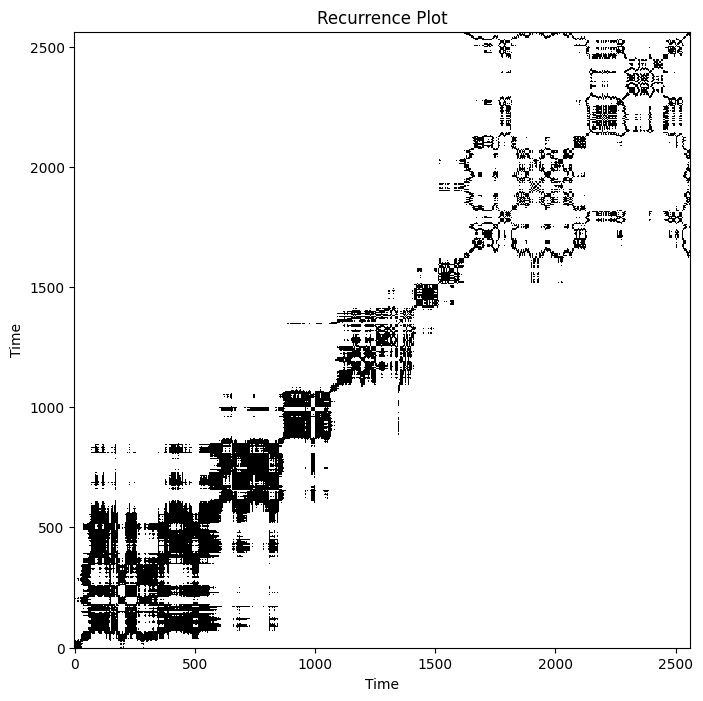

Recurrence Percentage: 8.178622161038563
Recurrence Entropy: 491.29735298658966


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

# Assuming 'features_df' is your DataFrame with a 'Close' column for time series data

# Normalize the data first (you may use other techniques)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(features_df[['Close']])

# Create a Recurrence Plot function
def recurrence_plot(data, threshold=0.1):
    """
    Generate a recurrence plot based on a distance threshold
    :param data: Time series data (2D array or DataFrame)
    :param threshold: Distance threshold for recurrence
    :return: Recurrence plot (binary matrix)
    """
    distance_matrix = cdist(data, data, 'euclidean')
    return (distance_matrix < threshold).astype(int)

# Generate Recurrence Plot for the 'Close' column
rp = recurrence_plot(data_scaled)

# Visualize the Recurrence Plot
plt.figure(figsize=(10, 8))
plt.imshow(rp, cmap='binary', origin='lower', interpolation='none')
plt.title('Recurrence Plot')
plt.xlabel('Time')
plt.ylabel('Time')
plt.show()

# Create a feature from the recurrence plot:
# Feature: Percentage of recurrence
recurrence_percentage = np.sum(rp) / rp.size * 100

# Feature: Recurrence entropy
def calculate_entropy(rp):
    """Calculate entropy from the recurrence plot."""
    prob_matrix = np.mean(rp, axis=0)
    prob_nonzero = prob_matrix[prob_matrix > 0]
    entropy = -np.sum(prob_nonzero * np.log(prob_nonzero))
    return entropy

recurrence_entropy = calculate_entropy(rp)

# Add the new features to your DataFrame
features_df['recurrence_percentage'] = recurrence_percentage
features_df['recurrence_entropy'] = recurrence_entropy

# Check the result
print(f"Recurrence Percentage: {recurrence_percentage}")
print(f"Recurrence Entropy: {recurrence_entropy}")


In [13]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

# Assuming 'features_df' is your DataFrame with a 'Close' column for time series data

# Normalize the data (if not already done)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(features_df[['Close']])

# Create a Recurrence Plot function
def recurrence_plot(data, threshold=0.1):
    """
    Generate a recurrence plot based on a distance threshold
    :param data: Time series data (2D array or DataFrame)
    :param threshold: Distance threshold for recurrence
    :return: Recurrence plot (binary matrix)
    """
    distance_matrix = cdist(data, data, 'euclidean')
    return (distance_matrix < threshold).astype(int)

# Calculate Recurrence Features over a Sliding Window (e.g., 30-day window)
window_size = 30
recurrence_percentages = []
recurrence_entropies = []

for i in range(window_size, len(features_df)):
    window_data = data_scaled[i-window_size:i]
    
    # Generate the recurrence plot for the current window
    rp = recurrence_plot(window_data)
    
    # Feature: Recurrence Percentage
    recurrence_percentage = np.sum(rp) / rp.size * 100
    recurrence_percentages.append(recurrence_percentage)
    
    # Feature: Recurrence Entropy
    def calculate_entropy(rp):
        """Calculate entropy from the recurrence plot."""
        prob_matrix = np.mean(rp, axis=0)
        prob_nonzero = prob_matrix[prob_matrix > 0]
        entropy = -np.sum(prob_nonzero * np.log(prob_nonzero))
        return entropy

    recurrence_entropy = calculate_entropy(rp)
    recurrence_entropies.append(recurrence_entropy)

# Add the new features to the DataFrame
features_df['recurrence_percentage'] = [None] * window_size + recurrence_percentages
features_df['recurrence_entropy'] = [None] * window_size + recurrence_entropies

# Check the result
print(features_df[['recurrence_percentage', 'recurrence_entropy']].head())


            recurrence_percentage  recurrence_entropy
Date                                                 
2014-12-01                    NaN                 NaN
2014-12-02                    NaN                 NaN
2014-12-03                    NaN                 NaN
2014-12-04                    NaN                 NaN
2014-12-05                    NaN                 NaN


In [14]:
features_df

,Open,High,Low,Close,Volume,Eurozone - GDP per capita,USA - GDP per capita,Eurozone - GDP Growth Rate,USA - GDP Growth Rate,China - GDP Growth Rate,...,VROC_12m,UlcerIndex,DPO,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,PVT,recurrence_percentage,recurrence_entropy
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-01,115.640205,116.315478,115.513596,115.851227,563831,39731.0,55817.563,0.004,0.020383,0.073,...,NaN,NaN,NaN,15.109890,7.294430,0.756364,5.517241,NaN,NaN,NaN
2014-12-02,116.273260,116.948534,115.724607,116.526489,628713,39731.0,55817.563,0.004,0.020383,0.073,...,3.603604,NaN,NaN,15.303867,7.308707,0.755596,5.522427,3664.581664,NaN,NaN
2014-12-03,116.231064,117.159567,116.188857,116.399879,519450,39731.0,55817.563,0.004,0.020383,0.073,...,2.608696,NaN,NaN,15.303867,7.308707,0.754513,5.514512,3100.182425,NaN,NaN
2014-12-04,116.231068,117.201778,114.289660,114.458488,1043572,39731.0,55817.563,0.004,0.020383,0.073,...,-4.090395,NaN,NaN,14.782609,7.311828,0.755515,5.524194,-14305.173052,NaN,NaN
2014-12-05,115.809004,117.412781,115.386960,117.412781,821623,39731.0,55817.563,0.004,0.020383,0.073,...,0.730443,NaN,NaN,15.500000,7.303665,0.755914,5.520942,6901.768720,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-25,332.899994,336.049988,329.850006,333.700012,724569,44814.0,65020.353,0.004,0.025123,0.046,...,-0.805369,3.151030,-0.018683,13.888889,4.478827,0.812364,3.638436,310401.921362,30.888889,10.521165
2024-11-26,331.149994,336.299988,328.399994,332.450012,322632,44814.0,65020.353,0.004,0.025123,0.046,...,0.703654,3.209342,-0.017788,13.768844,4.484452,0.812044,3.641571,309193.380801,32.888889,10.753656
2024-11-27,331.000000,333.399994,329.649994,332.850006,300479,44814.0,65020.353,0.004,0.025123,0.046,...,0.913733,3.217074,-0.008786,13.888889,4.493464,0.810182,3.640523,309554.908133,34.444444,10.719497


In [15]:
# Export the DataFrame to an Excel file
features_df.to_excel('features_df.xlsx', index=False)


In [16]:
features_df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Eurozone - GDP per capita',
       'USA - GDP per capita', 'Eurozone - GDP Growth Rate',
       'USA - GDP Growth Rate', 'China - GDP Growth Rate',
       'Eurozone - Monthly CPI', 'France - Monthly CPI', 'USA - Monthly CPI',
       'Brent Futures - 1 Month', 'Brent Futures - 2 Month',
       'Brent Futures - 3 Month', 'Brent Futures - 6 Month', 'EUR/USD Rates',
       'EUR/USD - 1 Month Vol', 'EUR/USD - 3 Month Vol',
       'EUR/USD - 6 Month Vol', 'EUR/USD - 12 Month Vol', 'MarketValue',
       'DividendYield', 'PriceToEarnings', 'EPS', 'PriceToCash', 'PriceToBook',
       'RSI', 'EMA_12', 'EMA_26', 'SMA_50', 'SMA_200', 'MACD', 'MACD_signal',
       'BB_high', 'BB_low', 'ADX', 'ATR', 'log_returns', 'lagged_return_5',
       'lagged_return_10', 'lagged_return_14', 'lagged_return_28', 'H_L',
       'O_C', 'momentum_5', 'momentum_10', 'stochastic_oscillator',
       'Williams_%R', 'OBV', 'CMF', 'PSAR', 'PSAR_down_indicator',
       'PSAR

In [17]:
# 1. Calculate the daily returns (percentage change)
features_df['daily_return'] = features_df['Close'].pct_change()

# 2. Label the 'y' variable as 1 (uptrend) if the return is positive, else 0 (downtrend)
features_df['y'] = np.where(features_df['daily_return'] > 0, 1, 0)

# Now, 'y' is the binary target variable for the classification problem

In [18]:
# Check the total number of NaN values in each column
nan_counts = features_df.isna().sum()

# Display the total NaN counts for each column
print(nan_counts)

Open                      0
High                      0
Low                       0
Close                     0
Volume                    0
                         ..
PVT                       1
recurrence_percentage    30
recurrence_entropy       30
daily_return              1
y                         0
Length: 100, dtype: int64


In [19]:
# Export the NaN counts to a CSV file
nan_counts.to_csv('nan_counts.csv', header=True)

# Output the path where the CSV file is saved
'nan_counts.csv'

'nan_counts.csv'

In [20]:
# Drop rows with NaN values and assign the result to a new dataframe
features_df_nonull = features_df.dropna()

# Display the updated DataFrame
features_df_nonull


,Open,High,Low,Close,Volume,Eurozone - GDP per capita,USA - GDP per capita,Eurozone - GDP Growth Rate,USA - GDP Growth Rate,China - GDP Growth Rate,...,DPO,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,PVT,recurrence_percentage,recurrence_entropy,daily_return,y
Date,,,,,,,,,,,,,,,,,,,,,
2015-09-14,124.672368,126.172896,123.429077,123.429077,614370,34282.0,57040.208,0.004,0.016106,0.070,...,0.006938,8.510638,4.692082,1.140000,5.348974,-22330.590128,50.888889,9.996582,-0.009291,0
2015-09-15,123.814904,126.344374,123.514807,125.829903,763478,34282.0,57040.208,0.004,0.016106,0.070,...,0.000655,8.858696,4.683908,1.140491,5.341954,-7480.139215,52.000000,9.703028,0.019451,1
2015-09-16,126.901743,129.945673,126.387272,129.131104,790799,34282.0,57040.208,0.004,0.016106,0.070,...,0.001676,9.329609,4.677871,1.142515,5.344538,13266.807967,53.555556,9.315825,0.026235,1
2015-09-17,129.688402,129.902763,128.530847,129.045319,472916,34282.0,57040.208,0.004,0.016106,0.070,...,0.014867,9.329609,4.677871,1.141916,5.341737,12952.638442,56.444444,8.792343,-0.000664,0
2015-09-18,128.230748,128.616596,125.143945,125.829903,1506497,34282.0,57040.208,0.004,0.016106,0.070,...,0.001462,8.858696,4.683908,1.140491,5.341954,-24584.674355,60.000000,8.222599,-0.024917,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-25,332.899994,336.049988,329.850006,333.700012,724569,44814.0,65020.353,0.004,0.025123,0.046,...,-0.018683,13.888889,4.478827,0.812364,3.638436,310401.921362,30.888889,10.521165,0.014132,1
2024-11-26,331.149994,336.299988,328.399994,332.450012,322632,44814.0,65020.353,0.004,0.025123,0.046,...,-0.017788,13.768844,4.484452,0.812044,3.641571,309193.380801,32.888889,10.753656,-0.003746,0
2024-11-27,331.000000,333.399994,329.649994,332.850006,300479,44814.0,65020.353,0.004,0.025123,0.046,...,-0.008786,13.888889,4.493464,0.810182,3.640523,309554.908133,34.444444,10.719497,0.001203,1


In [21]:
features_df_nonull.shape

(2343, 100)

In [22]:
daily_return_description = features_df_nonull['daily_return'].describe()

print(daily_return_description)

count    2343.000000
mean        0.000509
std         0.014065
min        -0.075803
25%        -0.007019
50%         0.000570
75%         0.007702
max         0.084374
Name: daily_return, dtype: float64


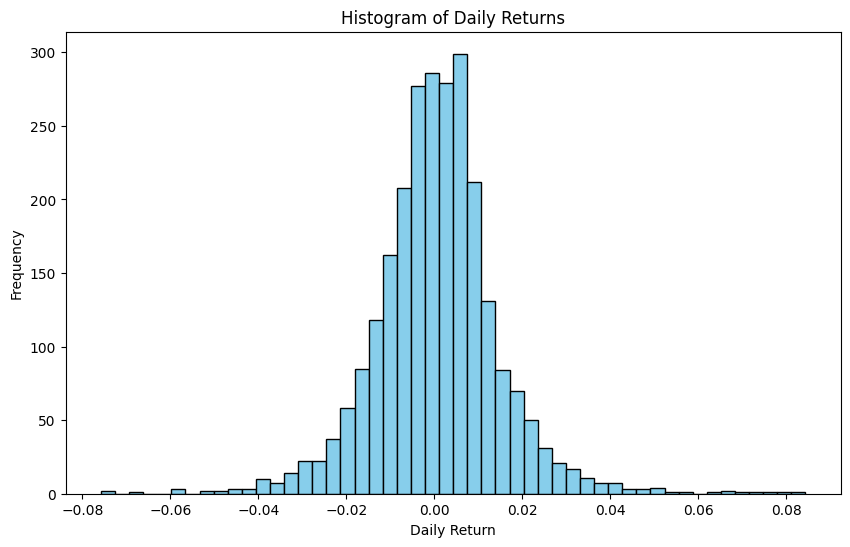

In [23]:
import matplotlib.pyplot as plt

# Plot histogram for the daily returns to understand the distribution
plt.figure(figsize=(10, 6))
plt.hist(features_df['daily_return'], bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()


In [24]:
# Calculate the variance of each feature (ignoring the target column 'y')
feature_variance = features_df_nonull.drop('y', axis=1).var()

# Display the variance of each feature
print(feature_variance)


Open                     9.982990e+03
High                     1.016593e+04
Low                      9.795565e+03
Close                    9.980313e+03
Volume                   5.910833e+10
                             ...     
CWM                      5.220230e-01
PVT                      1.852915e+10
recurrence_percentage    4.954696e+02
recurrence_entropy       1.619994e+01
daily_return             1.978291e-04
Length: 99, dtype: float64


In [25]:
# Set the threshold for low variance
variance_threshold = 0.001

# Identify low variance features
low_variance_features = feature_variance[feature_variance < variance_threshold].index

print(f"Low variance features: {low_variance_features}")


Low variance features: Index(['Eurozone - GDP Growth Rate', 'Eurozone - Monthly CPI',
       'France - Monthly CPI', 'USA - Monthly CPI', 'log_returns',
       'lagged_return_5', 'Brent_Futures_1M_log_return',
       'Brent_Futures_2M_log_return', 'Brent_Futures_3M_log_return',
       'Brent_Futures_6M_log_return', 'Brent_Futures_1M_volatility',
       'Brent_Futures_2M_volatility', 'Brent_Futures_3M_volatility',
       'Brent_Futures_6M_volatility', 'DPO', 'daily_return'],
      dtype='object')


Even though a feature may exhibit low variance, it could still hold valuable information under certain conditions. For instance, a feature that mostly assumes a constant value but changes under specific circumstances could be highly informative about those conditions. Therefore, the decision to remove a low variance feature should be well-considered, weighing the potential loss of subtle but important data against the simplicity and efficiency gained by its exclusion.

In [26]:
# Get summary statistics for all numerical features
features_df_nonull.describe()


,Open,High,Low,Close,Volume,Eurozone - GDP per capita,USA - GDP per capita,Eurozone - GDP Growth Rate,USA - GDP Growth Rate,China - GDP Growth Rate,...,DPO,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,PVT,recurrence_percentage,recurrence_entropy,daily_return,y
count,2343.000000,2343.000000,2343.000000,2343.000000,2.343000e+03,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000,...,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000,2343.000000
mean,264.638361,267.043498,262.169562,264.720154,4.802156e+05,39512.493811,60921.364211,0.004135,0.027099,0.056998,...,-0.000301,25.792610,6.637889,0.692935,4.508001,260442.317861,74.241950,5.140498,0.000509,0.519420
std,99.914914,100.826226,98.972546,99.901517,2.431220e+05,3374.280917,2682.017244,0.026553,0.077664,0.033058,...,0.012298,11.735962,1.323926,0.116954,0.722512,136121.838373,22.259147,4.024914,0.014065,0.499729
min,123.772056,125.615561,122.057165,123.386192,5.229300e+04,34282.000000,57040.208000,-0.108000,-0.280767,-0.069000,...,-0.040843,8.510638,4.478827,0.487154,3.635914,-80521.981563,26.666667,-0.000000,-0.075803,0.000000
25%,166.439713,167.662856,165.283242,166.484177,3.241740e+05,37060.000000,58703.144000,0.002000,0.019618,0.047000,...,-0.008132,17.112299,5.101358,0.615982,3.698184,143416.748130,54.666667,0.507914,-0.007019,0.000000
50%,243.288714,244.485791,240.894475,243.749146,4.280170e+05,39029.000000,60127.210000,0.005000,0.027555,0.063000,...,-0.000574,22.641509,6.920981,0.681065,5.058081,306403.692188,75.111111,5.635833,0.000570,1.000000
75%,355.901410,359.818903,352.337364,355.925034,5.701965e+05,42770.000000,63720.764000,0.007000,0.033827,0.069000,...,0.007749,31.936536,7.575758,0.737395,5.178142,375101.791337,98.222222,9.131940,0.007702,1.000000
max,457.950012,461.850006,456.149994,456.899994,2.569157e+06,44814.000000,65020.353000,0.108000,0.351954,0.187000,...,0.047288,63.225806,8.931860,1.143011,5.350000,453524.476764,100.000000,10.946127,0.084374,1.000000


In [27]:
# Calculate skewness and kurtosis for each feature
skewness = features_df_nonull.skew()
kurtosis = features_df_nonull.kurtosis()

# Combine skewness and kurtosis into a single DataFrame
skew_kurt_df = pd.DataFrame({
    'Feature': features_df_nonull.columns,
    'Skewness': skewness,
    'Kurtosis': kurtosis
})

# Save the DataFrame to a CSV file
skew_kurt_df.to_csv('skewness_kurtosis_summary.csv', index=False)

# Optionally, print the first few rows to check the output
print(skew_kurt_df.head())


       Feature  Skewness  Kurtosis
Open      Open  0.253637 -1.361276
High      High  0.246871 -1.370495
Low        Low  0.260204 -1.352231
Close    Close  0.252119 -1.361953
Volume  Volume  2.254064  9.822709


In [28]:
# Checking the class distribution in the 'y' column
y_class_distribution = features_df_nonull['y'].value_counts()
print(y_class_distribution)


y
1    1217
0    1126
Name: count, dtype: int64


In [29]:
print(features_df_nonull.isna().sum())

Open                     0
High                     0
Low                      0
Close                    0
Volume                   0
                        ..
PVT                      0
recurrence_percentage    0
recurrence_entropy       0
daily_return             0
y                        0
Length: 100, dtype: int64


In [31]:
features_df_nonull = features_df_nonull.astype(float)

In [32]:
# Calculate correlation between all features and the target 'y'
corr_matrix = features_df_nonull.corr()

# Extract the correlation of each feature with the target 'y'
target_corr = corr_matrix['y'].sort_values(ascending=False)

# Display the correlation between each feature and 'y'
print(target_corr)


y                        1.000000
log_returns              0.718843
daily_return             0.717842
stochastic_oscillator    0.374968
Williams_%R              0.374968
                           ...   
PSAR_down_indicator     -0.142761
VROC_3m                 -0.159618
VROC_12m                -0.161197
VROC_6m                 -0.171728
O_C                     -0.585255
Name: y, Length: 100, dtype: float64


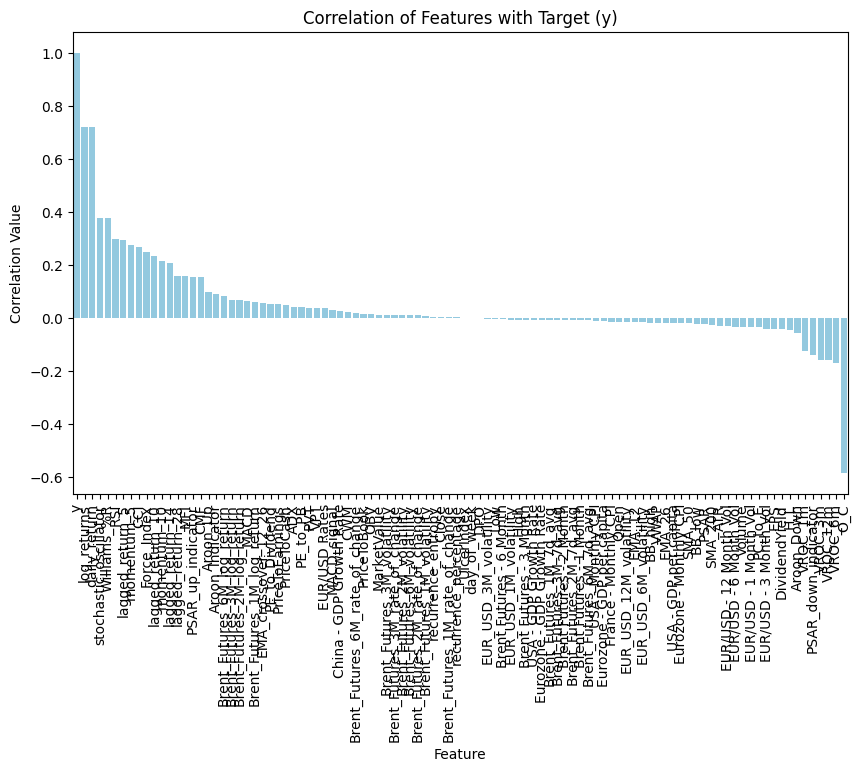

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Plot the correlation of features with 'y'
plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.index, y=target_corr.values, color='skyblue')  # Using color instead of palette
plt.title('Correlation of Features with Target (y)')
plt.xlabel('Feature')
plt.ylabel('Correlation Value')
plt.xticks(rotation=90)  # Rotate feature names for readability
plt.show()


In [34]:
# Step 4: Remove highly correlated features (correlation > 0.9)
# Exclude the target 'y' from the correlation calculation
features_without_y = features_df_nonull.drop('y', axis=1)

# Calculate the correlation matrix of the features excluding 'y'
corr_matrix = features_without_y.corr()

# Find the features with high correlation with 'y' (threshold = 0.9)
high_corr_features = target_corr[abs(target_corr) > 0.9].index

# Ensure that 'y' is not removed by excluding it from the drop list
high_corr_features = [feature for feature in high_corr_features if feature != 'y']

# Remove the features with high correlation (except for 'y')
features_df_cleaned = features_df_nonull.drop(columns=high_corr_features)

# Display the cleaned DataFrame shape
print(f"Shape before removing features: {features_df_nonull.shape}")
print(f"Shape after removing features: {features_df_cleaned.shape}")


Shape before removing features: (2343, 100)
Shape after removing features: (2343, 100)


In [35]:
# List columns with NaN values
columns_with_na = features_df_cleaned.columns[features_df_cleaned.isna().any()].tolist()

# Display the columns with NaN values
columns_with_na

[]

In [36]:
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Load your data
# Assuming 'features_df_cleaned' is your DataFrame and 'y' is the target variable
X = features_df_cleaned.drop(columns=['y'])  
y = features_df_cleaned['y']  

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Step 1: Boruta Feature Selection
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)
boruta = BorutaPy(rf, n_estimators='auto', random_state=42)
boruta.fit(X_train.values, y_train.values)

# Select Boruta features
boruta_features = X_train.columns[boruta.support_].tolist()
X_train_boruta = X_train[boruta_features]
X_test_boruta = X_test[boruta_features]

# Train a Random Forest model
rf.fit(X_train_boruta, y_train)
y_pred_boruta = rf.predict(X_test_boruta)

# Metrics for Boruta
acc_boruta = accuracy_score(y_test, y_pred_boruta)
f1_boruta = f1_score(y_test, y_pred_boruta)

# Step 2: Recursive Feature Elimination (RFE)
rfe = RFE(estimator=rf, n_features_to_select=10)  # Adjust number of features as desired
rfe.fit(X_train_boruta, y_train)

# Select RFE features
rfe_features = X_train_boruta.columns[rfe.support_].tolist()
X_train_rfe = X_train_boruta[rfe_features]
X_test_rfe = X_test_boruta[rfe_features]

# Train a Random Forest model
rf.fit(X_train_rfe, y_train)
y_pred_rfe = rf.predict(X_test_rfe)

# Metrics for RFE
acc_rfe = accuracy_score(y_test, y_pred_rfe)
f1_rfe = f1_score(y_test, y_pred_rfe)

# Step 3: Multicollinearity Filtering
correlation_matrix = X_train_rfe.corr().abs()
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Drop features with correlation > 0.9
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
X_train_multicollinear = X_train_rfe.drop(columns=to_drop)
X_test_multicollinear = X_test_rfe.drop(columns=to_drop)

# Train a Random Forest model
rf.fit(X_train_multicollinear, y_train)
y_pred_multicollinear = rf.predict(X_test_multicollinear)

# Metrics for Multicollinearity Filtering
acc_multicollinear = accuracy_score(y_test, y_pred_multicollinear)
f1_multicollinear = f1_score(y_test, y_pred_multicollinear)

# Summary of feature selection
summary = pd.DataFrame({
    'Stage': ['Boruta', 'RFE', 'Multicollinearity'],
    'Number of Features': [len(boruta_features), len(rfe_features), X_train_multicollinear.shape[1]],
    'Accuracy Score': [acc_boruta, acc_rfe, acc_multicollinear],
    'F1 Score': [f1_boruta, f1_rfe, f1_multicollinear]
})

print(summary)

               Stage  Number of Features  Accuracy Score  F1 Score
0             Boruta                  22             1.0       1.0
1                RFE                  10             1.0       1.0
2  Multicollinearity                   7             1.0       1.0


In [37]:
X.shape

(2343, 99)

In [38]:
y.shape

(2343,)

In [43]:
print(X_test_multicollinear.dtypes)


RSI                      float64
log_returns              float64
lagged_return_5          float64
O_C                      float64
stochastic_oscillator    float64
Force_Index              float64
VROC_3m                  float64
dtype: object


In [44]:
# Selecting the final features based on the feature selection steps
selected_features = [
    'RSI', 'log_returns', 'lagged_return_5', 'O_C', 
    'stochastic_oscillator', 'Force_Index', 'VROC_3m'
]

# Create the final dataframe with selected features and the target variable 'y'
final_df_lstm = features_df_cleaned[selected_features + ['y']]


In [45]:
final_df_lstm

,RSI,log_returns,lagged_return_5,O_C,stochastic_oscillator,Force_Index,VROC_3m,y
Date,,,,,,,,
2015-09-14,32.728510,-0.009335,-0.022079,1.243291,1.726407e-13,-822194.701551,-0.907029,0.0
2015-09-15,38.655772,0.019264,-0.001021,-2.014999,2.916645e+01,-442884.393977,-0.686499,1.0
2015-09-16,45.735765,0.025897,0.013459,-2.229360,6.927112e+01,-6674.288526,-1.262673,1.0
2015-09-17,45.588521,-0.000665,0.031882,0.643083,6.822896e+01,-11516.398378,0.578736,0.0
2015-09-18,40.345428,-0.025233,0.009979,2.400846,2.916645e+01,-701873.268516,-2.895592,0.0
...,...,...,...,...,...,...,...,...
2024-11-25,42.884249,0.014033,0.027085,-0.800018,4.683718e+01,372878.631522,-1.806452,1.0
2024-11-26,41.974580,-0.003753,0.032614,-1.300018,5.446884e+01,261997.398448,1.971091,0.0
2024-11-27,42.395664,0.001202,0.039507,-1.850006,5.610176e+01,241739.165244,0.489691,1.0


In [48]:
final_df_lstm.shape

(2343, 8)

In [50]:
final_df_lstm.to_csv('final_df_lstm.csv', index=True)
